In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import pandas as pd
import numpy as np
import plotly.express as px
from datetime import datetime
from utils import BaseStrategy, TradeMonitor

data = pd.read_parquet('data.parquet')
if data.index.tz is not None:
    data.index = data.index.tz_localize(None)
data['date'] = data.index.date

class StrategyQuality(BaseStrategy):
    def __init__(self, data, window_days=5, top_k=5):
        df = data.copy()
        df['date'] = df.index.date
        super().__init__(df)
        self.cash = self.capital
        self.window = window_days
        self.k = top_k

    def before_open(self, day) -> dict:
        if hasattr(day, 'tzinfo') and day.tzinfo is not None:
            day = day.tz_localize(None)

        hist = self.data[self.data['date'] < day.date()]
        if hist.empty:
            return {'selected': []}

        recent = hist.loc[hist.index >= (day - pd.Timedelta(days=self.window + 2))]
        if recent.empty:
            return {'selected': []}

        df = recent.copy()
        df['date'] = df.index.date
        daily = df.groupby(['symbol', 'date']).agg(
            open=('price', 'first'),
            close=('price', 'last'),
            volatility=('price', 'std'),
            volume=('size', 'sum'),
            bid=('bid_px_00', 'mean'),
            ask=('ask_px_00', 'mean')
        ).reset_index()
        daily['spread'] = (daily['ask'] - daily['bid']) / daily['open']
        daily['return'] = daily['close'] / daily['open'] - 1

        qf = (daily.groupby('symbol')
              .agg({'spread': 'mean', 'volume': 'mean', 'volatility': 'mean', 'return': 'mean'})
              .dropna())

        qf['spread_score'] = -qf['spread'].rank()
        qf['volume_score'] = qf['volume'].rank()
        med = qf['volatility'].median()
        qf['volatility_score'] = (-abs(qf['volatility'] - med)).rank()
        qf['quality_score'] = (0.9 * qf['volatility_score'] +
                               0.6 * qf['spread_score'] +
                               0.1 * qf['volume_score'])

        today_syms = set(self.data[self.data['date'] == day.date()]['symbol'])
        qf = qf.loc[qf.index.isin(today_syms)]
        if qf.empty:
            return {'selected': list(today_syms)[:self.k]}

        sel = qf.sort_values('quality_score', ascending=False).head(self.k).index.tolist()
        return {'selected': sel}

    def trading_session(self, day, params) -> None:
        sel = params.get('selected', [])
        if not sel:
            return

        today = self.data[self.data['date'] == day.date()]
        if today.empty:
            return

        held = self.qts[self.qts != 0].index.tolist()
        for sym in held:
            if sym not in sel:
                df_sym = today[today.symbol == sym]
                if not df_sym.empty:
                    ft = df_sym.iloc[0]
                    self.trade(ft.name, sym, 'NYSE', ft.price, self.qts[sym], 'SELL')

        cash_each = self.cash / len(sel)
        for sym in sel:
            df_sym = today[today.symbol == sym]
            if not df_sym.empty:
                ft = df_sym.iloc[0]
                qty = cash_each / ft.price
                if qty > 0:
                    self.trade(ft.name, sym, 'NYSE', ft.price, qty, 'BUY')

    def after_close(self, day) -> float:
        today = self.data[self.data['date'] == day.date()]
        closes = today.groupby('symbol').price.last()
        closes = closes.reindex(self.qts.index).fillna(0)
        nav = self.cash + (self.qts * closes).sum()
        return nav

# Definimos rango de fechas 
start = datetime(2023, 3, 28)
end   = datetime(2023, 12, 29)

strategy = StrategyQuality(data, window_days=5, top_k=5)

all_days    = sorted(data['date'].unique())
trading_days = [pd.to_datetime(d) for d in all_days if start <= pd.to_datetime(d) <= end]

pnl, idx = [], []
for day in trading_days:
    params = strategy.before_open(day)
    strategy.trading_session(day, params)
    pnl.append(strategy.after_close(day))
    idx.append(day)
strategy.pnl_history = pd.Series(pnl, index=idx)

def calculate_sharpe_and_cvar(strat):
    eq    = strat.pnl_history.ffill()
    daily = eq.diff().dropna()
    if daily.std() == 0:
        print("Equity plano: Sharpe/CVaR no disponibles")
        return np.nan, np.nan
    sharpe = np.sqrt(252) * daily.mean() / daily.std()
    var95  = daily.quantile(0.05)
    cvar95 = daily[daily <= var95].mean()
    print(f"Sharpe Ratio: {sharpe:.4f}   CVaR(95%): {cvar95:.2f}")
    return sharpe, cvar95

sharpe, cvar = calculate_sharpe_and_cvar(strategy)


eq = strategy.pnl_history.ffill()
fig = px.line(eq,
              title="Equity Curve (NAV)",
              labels={'index': 'Fecha', 'value': 'Capital ($)'},
              template='plotly_white')
fig.update_layout(showlegend=False)
fig.show()


from IPython.display import display
td = strategy.trade_monitor.trades
print(f"\nTotal operaciones: {len(td)}")
display(td.head(10))


Sharpe Ratio: 1.7453   CVaR(95%): -24106.70



Total operaciones: 668


,time,symbol,exchange,price,qty,side
0,2023-03-29 09:30:00.985029729,E,NYSE,31.180,3207.184092,BUY
1,2023-03-29 09:30:04.873111543,F,NYSE,10.380,9633.911368,BUY
2,2023-03-29 09:30:50.454946480,I,NYSE,17.710,5646.527386,BUY
3,2023-03-29 09:30:03.097014870,A,NYSE,10.245,9760.858956,BUY
4,2023-03-29 09:30:31.837035412,M,NYSE,7.720,12953.367876,BUY
5,2023-03-30 09:30:04.189478900,M,NYSE,7.710,12953.367876,SELL
6,2023-03-30 09:30:01.295906997,E,NYSE,31.765,628.808225,BUY
7,2023-03-30 09:32:40.420818984,I,NYSE,18.050,1106.597965,BUY
8,2023-03-30 09:30:12.691007658,F,NYSE,10.455,1910.482378,BUY
9,2023-03-30 09:30:02.714314934,A,NYSE,10.575,1888.803146,BUY


In [4]:
# Etapa experimental de la data

import pandas as pd

df = pd.read_parquet('data.parquet')                  # carga raw
df = df.sort_index()                                  # ordenar cronológicamente


In [5]:
# 1.Crear variables claves

# Mid price
df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2

# Spread absoluto y relativo
df['spread_abs'] = df['ask_px_00'] - df['bid_px_00']
df['spread_rel'] = df['spread_abs'] / df['mid_price']

#Fecha y Minuto
df['date'] = df.index.date
df['minute'] = df.index.floor('T')   # redondea al minuto

df['vol_price'] = df['price'] * df['size']  # volumen ponderado por precio



In [23]:
# 2.Estadísticas Descriptivas por Símbolo

# Vol total y N de Operaciones
stats = (df
         .groupby('symbol')
         .agg(total_trades=('size','count'),
              total_volume=('size','sum'),
              avg_spread=('spread_rel','mean'),
              vol_mid=('mid_price','std'),
              vol_price=('vol_price','sum')),
        )
stats

(        total_trades  total_volume  avg_spread    vol_mid     vol_price
 symbol                                                                 
 A            1245176     293543290    0.000724   1.594738  4.049332e+09
 B             343064      19479084    0.004685   9.659958  1.253430e+09
 C             707596      30904220    0.002793  36.679339  5.408631e+09
 D             400375      32857873    0.001135   2.317564  4.524400e+08
 E            1296328     102505724    0.000407   2.360318  2.861789e+09
 F             391648      36764178    0.000907   1.125747  4.138943e+08
 G             464973      24621104    0.002757   2.946517  1.096410e+09
 H              18899        883827    0.033560   1.176866  1.855766e+07
 I              95202       5858087    0.008425   1.015889  1.102222e+08
 J              25723       1300040    0.044253   1.891955  1.822648e+07
 K             132526      19203756    0.003286   0.284834  6.110249e+07
 L             407302      15697631    0.005479   7

In [24]:
# 3. Series de Retornos a Intervalos Fijos

# Resampleo intradía
mid_panel = (df
             .pivot_table(index='minute', columns='symbol', values='mid_price')
             .ffill() 
            )

# Log returns
returns = np.log(mid_panel
).diff().dropna() 



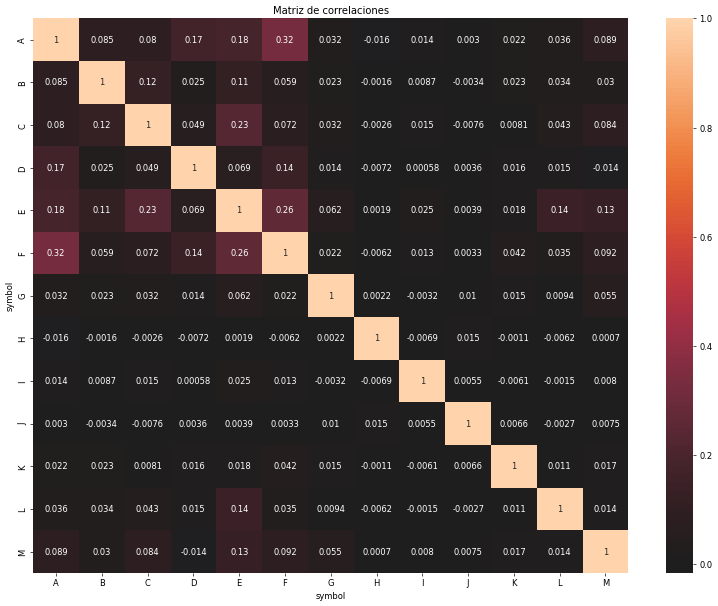

In [22]:
# 4.Matriz de Correlación

import seaborn as sn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

corr = returns.corr()

plt.figure(figsize=(16, 12), dpi=60)
sn.heatmap(corr, annot=True, center=0)
plt.title('Matriz de correlaciones')
plt.show()


/var/folders/rd/t5963ll176gcvb88jzbrz0f80000gn/T/ipykernel_4079/1459828094.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(1 - corr, method='average')


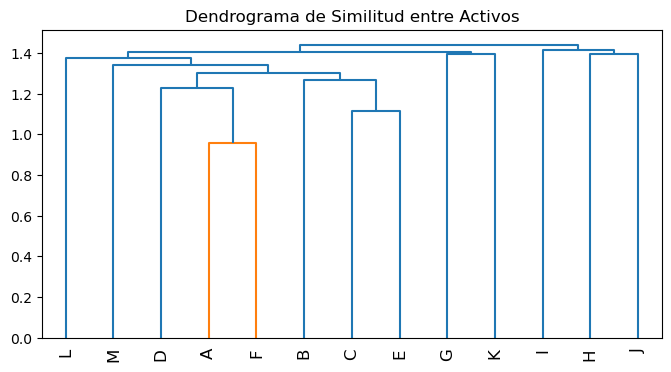

In [9]:
# 5.Annálsis de Clusters

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(1 - corr, method='average')
plt.figure(figsize=(8,4))
dendrogram(Z, labels=corr.columns, leaf_rotation=90)
plt.title('Dendrograma de Similitud entre Activos')
plt.show()


In [7]:
import numpy as np

def calculate_cvar_pct(nav_series, confidence_level=0.95):
    """
    Calcula el CVaR (en %) de una serie de NAV diarios.
    
    Parámetros:
    - nav_series: pd.Series con el NAV de cada día.
    - confidence_level: nivel de confianza para el VaR (por defecto 0.95).
    
    Retorna:
    - cvar_pct: CVaR al nivel especificado, en porcentaje negativo.
    """
    # Calcula retornos diarios
    returns = nav_series.pct_change().dropna()
    # Percentil de VaR
    var = returns.quantile(1 - confidence_level)
    # CVaR: promedio de las pérdidas que superan el VaR
    cvar = returns[returns <= var].mean()
    # Convertir a porcentaje
    cvar_pct = cvar * 100
    return cvar_pct

# Ejemplo de uso:
# supongamos strategy.pnl_history es tu pd.Series de NAV diario
cvar_percent = calculate_cvar_pct(strategy.pnl_history)
print(f"CVaR (95%) en % diario: {cvar_percent:.2f}%")


CVaR (95%) en % diario: -3.65%
